# 🫀 ECG Multi-Label Classification — Kaggle Training (All Models)

Self-contained notebook that trains **all 7 models** sequentially on Kaggle GPU.  
After training, download `outputs/` and resume locally.

**Dataset**: Add `ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1` as a Kaggle dataset.

**Loss**: Asymmetric Focal Loss (γ⁺=1.0, γ⁻=4.0, clip=0.05) with AMP enabled.

**Models trained (in order)**:
1. CNN 1D
2. Leadwise CNN
3. Pretrained ResNet 1D (xresnet-D)
4. BiLSTM (Bidirectional + Attention)
5. Transformer
6. CNN-BiLSTM
7. CNN-Transformer

## 1. Setup & Install

In [1]:
%pip install -q wfdb scikit-learn scipy

import ast, json, logging, math, os, random, shutil, time, gc
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from scipy.signal import butter, filtfilt
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, roc_auc_score, average_precision_score)
from torch.optim.lr_scheduler import CosineAnnealingLR, ReduceLROnPlateau, StepLR
from torch.utils.data import DataLoader, Dataset
import wfdb

logging.basicConfig(level=logging.INFO, format='%(asctime)s | %(levelname)s | %(message)s')
logger = logging.getLogger(__name__)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'PyTorch {torch.__version__} | Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    if torch.cuda.device_count() > 1:
        print(f'Multi-GPU: {torch.cuda.device_count()} GPUs available')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 4.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
PyTorch 2.10.0+cu128 | Device: cuda
GPU: Tesla T4
Multi-GPU: 2 GPUs available


## 2. Configuration

In [2]:
# ═══════════════════════════════════════════════════════════
#  DATA PATH — update to your Kaggle dataset path
# ═══════════════════════════════════════════════════════════
DATA_DIR = "/kaggle/input/datasets/khyeh0719/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1"

# ═══════════════════════════════════════════════════════════
#  PERFORMANCE / STABILITY CONTROLS
# ═══════════════════════════════════════════════════════════
CACHE_PREPROCESSED = True
PREPROCESSED_CACHE_PATH = Path("outputs/cache/preprocessed_signals_sr100.npz")

# Multi-GPU mode:
#   - "single": force single GPU (often faster for smaller models)
#   - "dataparallel": use nn.DataParallel if multiple GPUs are visible
MULTI_GPU_MODE = "dataparallel"
FORCE_SINGLE_GPU_MODELS = {"cnn_1d", "leadwise_cnn", "lstm"}

# If False, asymmetric focal runs will train in full precision for stability.
USE_AMP_FOR_ASYMMETRIC_FOCAL = True

# Optional compile (can help some models, but compile overhead is non-trivial on short runs)
ENABLE_TORCH_COMPILE = False
TORCH_COMPILE_MODE = "reduce-overhead"

# Early stopping target
EARLY_STOPPING_MONITOR = "f1_macro"  # "f1_macro" or "val_loss"
EARLY_STOPPING_MODE = "max"          # "max" for f1, "min" for val_loss
EARLY_STOPPING_MIN_DELTA = 1e-4

# Per-class threshold search grid (finer than 0.05 steps)
THRESHOLD_GRID = np.arange(0.05, 0.951, 0.01)

MODELS_TO_TRAIN = [
    "cnn_1d",
    "leadwise_cnn",
    "pretrained_resnet",
    "lstm",
    "transformer",
    "cnn_lstm",
    "cnn_transformer",
]

# ═══════════════════════════════════════════════════════════
#  Model-specific hyperparameters
# ═══════════════════════════════════════════════════════════
MODEL_CONFIGS = {
    "cnn_1d": dict(
        params=dict(base_filters=64, n_blocks=4, kernel_size=7, dropout=0.3),
        batch_size=128, lr=1e-3, epochs=50, patience=10,
    ),
    "leadwise_cnn": dict(
        params=dict(base_filters=32, n_blocks=3, kernel_size=7, dropout=0.3),
        batch_size=64, lr=1e-3, epochs=60, patience=10,
    ),
    "pretrained_resnet": dict(
        params=dict(base_filters=64, layers=[2,2,2,2], kernel_size=7, dropout=0.2),
        batch_size=64, lr=5e-4, epochs=80, patience=10,
    ),
    "lstm": dict(
        params=dict(hidden_size=128, num_layers=2, dropout=0.3),
        batch_size=64, lr=1e-3, epochs=50, patience=10,
    ),
    "transformer": dict(
        params=dict(d_model=128, nhead=8, num_layers=4, dim_feedforward=256, dropout=0.1),
        batch_size=64, lr=3e-4, epochs=60, patience=10,
    ),
    "cnn_lstm": dict(
        params=dict(cnn_filters=64, n_cnn_blocks=3, kernel_size=7, lstm_hidden=128, lstm_layers=2, dropout=0.3),
        batch_size=64, lr=1e-3, epochs=50, patience=10,
    ),
    "cnn_transformer": dict(
        params=dict(cnn_filters=64, n_cnn_blocks=3, kernel_size=7, d_model=128, nhead=8,
                    num_transformer_layers=3, dim_feedforward=256, dropout=0.1),
        batch_size=64, lr=3e-4, epochs=60, patience=10,
    ),
}

TRAIN_RUNS = [
    dict(run_id=m, model_name=m, ablation="standard", overrides={})
    for m in MODELS_TO_TRAIN
]

print(f"Total runs planned: {len(TRAIN_RUNS)}")
for i, run in enumerate(TRAIN_RUNS[:8], start=1):
    print(f"  {i}. {run['run_id']}")
if len(TRAIN_RUNS) > 8:
    print(f"  ... and {len(TRAIN_RUNS)-8} more")
print(f"MULTI_GPU_MODE = {MULTI_GPU_MODE}")
print(f"EARLY_STOPPING_MONITOR = {EARLY_STOPPING_MONITOR}")

Total runs planned: 7
  1. cnn_1d
  2. leadwise_cnn
  3. pretrained_resnet
  4. lstm
  5. transformer
  6. cnn_lstm
  7. cnn_transformer
MULTI_GPU_MODE = dataparallel
EARLY_STOPPING_MONITOR = f1_macro


## 3. Data Pipeline

In [3]:
# ── Label constants ──
DIAGNOSTIC_SUPERCLASSES = ["NORM", "MI", "STTC", "CD", "HYP"]

def load_metadata(data_dir):
    df = pd.read_csv(Path(data_dir) / "ptbxl_database.csv", index_col="ecg_id")
    df.scp_codes = df.scp_codes.apply(ast.literal_eval)
    return df

def load_scp_statements(data_dir):
    return pd.read_csv(Path(data_dir) / "scp_statements.csv", index_col=0)

def load_raw_signals(metadata_df, data_dir, sampling_rate=100):
    data_path = str(Path(data_dir)) + "/"
    filenames = metadata_df.filename_lr if sampling_rate == 100 else metadata_df.filename_hr
    signals = [wfdb.rdsamp(data_path + f)[0] for f in filenames]
    return np.array(signals, dtype=np.float32)

def aggregate_diagnostics(metadata_df, scp_df, label_type="diagnostic_superclass"):
    diag_df = scp_df[scp_df.diagnostic == 1.0]
    col = "diagnostic_class" if label_type == "diagnostic_superclass" else "diagnostic_subclass"
    def _agg(scp_dict):
        return list(set(
            diag_df.loc[c][col] for c in scp_dict if c in diag_df.index and pd.notna(diag_df.loc[c][col])
        ))
    return metadata_df.scp_codes.apply(_agg)

def encode_labels(diag_labels, label_classes=None):
    if label_classes is None:
        label_classes = DIAGNOSTIC_SUPERCLASSES
    idx_map = {c: i for i, c in enumerate(label_classes)}
    matrix = np.zeros((len(diag_labels), len(label_classes)), dtype=np.float32)
    for i, labels in enumerate(diag_labels):
        for l in labels:
            if l in idx_map:
                matrix[i, idx_map[l]] = 1.0
    return matrix, label_classes

def compute_class_weights(label_matrix):
    counts = np.where(label_matrix.sum(0) == 0, 1, label_matrix.sum(0))
    return (label_matrix.shape[0] / (label_matrix.shape[1] * counts)).astype(np.float32)

In [4]:
# ── Preprocessing ──

def bandpass_filter(signal, lowcut=0.5, highcut=40.0, fs=100.0, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    axis = 0 if signal.ndim == 2 else 1
    return filtfilt(b, a, signal, axis=axis).astype(np.float32)

def remove_baseline_wander(signal, fs=100.0, cutoff=0.5, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, cutoff/nyq, btype='high')
    axis = 0 if signal.ndim == 2 else 1
    return filtfilt(b, a, signal, axis=axis).astype(np.float32)

def preprocess_pipeline(signals, config=None):
    signals = remove_baseline_wander(signals)
    signals = bandpass_filter(signals)
    high = np.percentile(np.abs(signals), 99)
    signals = np.clip(signals, -high, high).astype(np.float32)
    mean = signals.mean(axis=1, keepdims=True)
    std = np.where(signals.std(axis=1, keepdims=True) == 0, 1.0, signals.std(axis=1, keepdims=True))
    signals = ((signals - mean) / std).astype(np.float32)
    print(f"Preprocessed: {signals.shape}")
    return signals

class ECGDataset(Dataset):
    def __init__(self, signals, labels):
        self.signals = signals
        self.labels = labels
    def __len__(self):
        return len(self.signals)
    def __getitem__(self, idx):
        return (torch.tensor(self.signals[idx], dtype=torch.float32).permute(1, 0),
                torch.tensor(self.labels[idx], dtype=torch.float32))

## 4. Load & Preprocess Data (once)

In [5]:
metadata = load_metadata(DATA_DIR)

if CACHE_PREPROCESSED and PREPROCESSED_CACHE_PATH.exists():
    cached = np.load(PREPROCESSED_CACHE_PATH)
    signals = cached["signals"].astype(np.float32)
    print(f"Loaded cached preprocessed signals: {signals.shape} from {PREPROCESSED_CACHE_PATH}")
else:
    raw_signals = load_raw_signals(metadata, DATA_DIR, sampling_rate=100)
    signals = preprocess_pipeline(raw_signals)
    if CACHE_PREPROCESSED:
        PREPROCESSED_CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
        np.savez_compressed(PREPROCESSED_CACHE_PATH, signals=signals)
        print(f"Saved preprocessed cache to {PREPROCESSED_CACHE_PATH}")

scp_df = load_scp_statements(DATA_DIR)
diag_labels = aggregate_diagnostics(metadata, scp_df)
label_matrix, label_classes = encode_labels(diag_labels)
class_weights = compute_class_weights(label_matrix)

# Splits
folds = metadata.strat_fold.values
train_idx = np.where((folds != 9) & (folds != 10))[0]
val_idx = np.where(folds == 9)[0]
test_idx = np.where(folds == 10)[0]

print(f"Samples — Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}")
print(f"Classes: {label_classes}")
print(f"Weights: {class_weights.round(3)}")

Preprocessed: (21837, 1000, 12)
Saved preprocessed cache to outputs/cache/preprocessed_signals_sr100.npz
Samples — Train: 17441 | Val: 2193 | Test: 2203
Classes: ['NORM', 'MI', 'STTC', 'CD', 'HYP']
Weights: [0.458 0.796 0.832 0.89  1.645]


## 5. Model Definitions

In [6]:
# ── CNN 1D ──
class CNN1D(nn.Module):
    def __init__(self, input_channels=12, num_classes=5, base_filters=64, n_blocks=4, kernel_size=7, dropout=0.3, **kw):
        super().__init__()
        blocks, in_ch = [], input_channels
        for i in range(n_blocks):
            out_ch = base_filters * (2**i)
            blocks.append(nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size, padding=kernel_size//2),
                nn.BatchNorm1d(out_ch), nn.ReLU(True), nn.MaxPool1d(2, 2)))
            in_ch = out_ch
        self.features = nn.Sequential(*blocks)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(in_ch, num_classes)
    def forward(self, x):
        return self.fc(self.dropout(self.pool(self.features(x)).squeeze(-1)))

# ── Leadwise CNN ──
class LeadwiseCNN(nn.Module):
    def __init__(self, input_channels=12, num_classes=5, base_filters=32, n_blocks=3, kernel_size=7, dropout=0.3, **kw):
        super().__init__()
        self.n_leads = input_channels
        layers, in_ch = [], 1
        for i in range(n_blocks):
            out_ch = base_filters * (2**i)
            layers.append(nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size, padding=kernel_size//2),
                nn.BatchNorm1d(out_ch), nn.ReLU(True), nn.MaxPool1d(2, 2)))
            in_ch = out_ch
        self.backbone = nn.Sequential(*layers)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(in_ch * self.n_leads, 128),
            nn.ReLU(True), nn.Dropout(dropout), nn.Linear(128, num_classes))
    def forward(self, x):
        feats = [self.pool(self.backbone(x[:, i:i+1, :])).squeeze(-1) for i in range(self.n_leads)]
        return self.classifier(torch.cat(feats, 1))

# ── Pretrained ResNet 1D (xresnet-D) ──
class PretrainedResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=7, stride=1, dropout=0.1):
        super().__init__()
        pad = kernel_size // 2
        self.bn1 = nn.BatchNorm1d(in_ch)
        self.relu1 = nn.ReLU(True)
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size, stride=stride, padding=pad)
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.relu2 = nn.ReLU(True)
        self.do = nn.Dropout(dropout)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size, padding=pad)
        self.needs_proj = (stride != 1 or in_ch != out_ch)
        self.skip = (nn.Sequential(nn.Conv1d(in_ch, out_ch, 1, stride=stride), nn.BatchNorm1d(out_ch))
                     if self.needs_proj else nn.Identity())
    def forward(self, x):
        identity = self.skip(x)
        out = self.conv1(self.relu1(self.bn1(x)))
        out = self.conv2(self.do(self.relu2(self.bn2(out))))
        if out.shape[-1] != identity.shape[-1]:
            ml = min(out.shape[-1], identity.shape[-1])
            out, identity = out[..., :ml], identity[..., :ml]
        return out + identity

class PretrainedResNet1D(nn.Module):
    def __init__(self, input_channels=12, num_classes=5, base_filters=64, layers=None,
                 kernel_size=7, dropout=0.2, **kw):
        super().__init__()
        if layers is None: layers = [2,2,2,2]
        bf = base_filters
        self.stem = nn.Sequential(
            nn.Conv1d(input_channels, bf//2, 7, stride=2, padding=3), nn.BatchNorm1d(bf//2), nn.ReLU(True),
            nn.Conv1d(bf//2, bf//2, 3, padding=1), nn.BatchNorm1d(bf//2), nn.ReLU(True),
            nn.Conv1d(bf//2, bf, 3, padding=1), nn.BatchNorm1d(bf), nn.ReLU(True),
            nn.MaxPool1d(3, 2, 1))
        fs = [bf, bf*2, bf*4, bf*8]
        def stg(ic, oc, n, s):
            return nn.Sequential(PretrainedResBlock(ic, oc, kernel_size, s, dropout),
                                 *[PretrainedResBlock(oc, oc, kernel_size, 1, dropout) for _ in range(n-1)])
        self.stage1 = stg(bf, fs[0], layers[0], 1)
        self.stage2 = stg(fs[0], fs[1], layers[1], 2)
        self.stage3 = stg(fs[1], fs[2], layers[2], 2)
        self.stage4 = stg(fs[2], fs[3], layers[3], 2)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(fs[3], num_classes))
    def forward(self, x):
        x = self.stage4(self.stage3(self.stage2(self.stage1(self.stem(x)))))
        return self.head(self.pool(x).squeeze(-1))
    def save_backbone(self, path):
        torch.save({k: v for k, v in self.state_dict().items() if not k.startswith("head.")}, path)

# ── LSTM ──
class LSTMModel(nn.Module):
    def __init__(self, input_channels=12, num_classes=5, hidden_size=128, num_layers=2, dropout=0.3, **kw):
        super().__init__()
        self.lstm = nn.LSTM(input_channels, hidden_size, num_layers, batch_first=True,
                            bidirectional=True, dropout=dropout if num_layers > 1 else 0.0)
        dim = hidden_size * 2
        self.attn = nn.Sequential(nn.Linear(dim, 64), nn.Tanh(), nn.Linear(64, 1))
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(dim, num_classes)
    def forward(self, x):
        x = x.permute(0, 2, 1)
        out, _ = self.lstm(x)
        w = torch.softmax(self.attn(out), dim=1)
        return self.fc(self.dropout((out * w).sum(1)))

# ── Transformer ──
class TransformerModel(nn.Module):
    def __init__(self, input_channels=12, num_classes=5, d_model=128, nhead=8,
                 num_layers=4, dim_feedforward=256, dropout=0.1, max_seq_len=5000, **kw):
        super().__init__()
        self.proj = nn.Linear(input_channels, d_model)
        pe = torch.zeros(max_seq_len, d_model)
        pos = torch.arange(max_seq_len).float().unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div); pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))
        self.pe_drop = nn.Dropout(dropout)
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))
        layer = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward, dropout, batch_first=True, activation='gelu')
        self.encoder = nn.TransformerEncoder(layer, num_layers)
        self.fc = nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, num_classes))
    def forward(self, x):
        x = self.proj(x.permute(0, 2, 1))
        x = torch.cat([self.cls_token.expand(x.size(0), -1, -1), x], 1)
        x = self.pe_drop(x + self.pe[:, :x.size(1)])
        return self.fc(self.encoder(x)[:, 0])

# ── CNN-LSTM ──
class CNNLSTM(nn.Module):
    def __init__(self, input_channels=12, num_classes=5, cnn_filters=64, n_cnn_blocks=3,
                 kernel_size=7, lstm_hidden=128, lstm_layers=2, dropout=0.3, **kw):
        super().__init__()
        layers, in_ch = [], input_channels
        for i in range(n_cnn_blocks):
            out_ch = cnn_filters * (2**i)
            layers.append(nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size, padding=kernel_size//2),
                nn.BatchNorm1d(out_ch), nn.ReLU(True), nn.MaxPool1d(2, 2)))
            in_ch = out_ch
        self.cnn = nn.Sequential(*layers)
        self.lstm = nn.LSTM(in_ch, lstm_hidden, lstm_layers, batch_first=True,
                            bidirectional=True, dropout=dropout if lstm_layers > 1 else 0.0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(lstm_hidden * 2, num_classes)
    def forward(self, x):
        x = self.cnn(x).permute(0, 2, 1)
        _, (h, _) = self.lstm(x)
        return self.fc(self.dropout(torch.cat([h[-2], h[-1]], 1)))

# ── CNN-Transformer ──
class CNNTransformer(nn.Module):
    def __init__(self, input_channels=12, num_classes=5, cnn_filters=64, n_cnn_blocks=3,
                 kernel_size=7, d_model=128, nhead=8, num_transformer_layers=3,
                 dim_feedforward=256, dropout=0.1, **kw):
        super().__init__()
        layers, in_ch = [], input_channels
        for i in range(n_cnn_blocks):
            out_ch = cnn_filters * (2**i)
            layers.append(nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size, padding=kernel_size//2),
                nn.BatchNorm1d(out_ch), nn.ReLU(True), nn.MaxPool1d(2, 2)))
            in_ch = out_ch
        self.cnn = nn.Sequential(*layers)
        self.proj = nn.Linear(in_ch, d_model)
        pe = torch.zeros(5000, d_model)
        pos = torch.arange(5000).float().unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div); pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))
        self.pe_drop = nn.Dropout(dropout)
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))
        layer = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward, dropout, batch_first=True, activation='gelu')
        self.transformer = nn.TransformerEncoder(layer, num_transformer_layers)
        self.fc = nn.Sequential(nn.LayerNorm(d_model), nn.Dropout(dropout), nn.Linear(d_model, num_classes))
    def forward(self, x):
        x = self.proj(self.cnn(x).permute(0, 2, 1))
        x = torch.cat([self.cls_token.expand(x.size(0), -1, -1), x], 1)
        x = self.pe_drop(x + self.pe[:, :x.size(1)])
        return self.fc(self.transformer(x)[:, 0])

# ── Model Registry ──
MODEL_REGISTRY = {
    'cnn_1d': CNN1D, 'leadwise_cnn': LeadwiseCNN,
    'pretrained_resnet': PretrainedResNet1D, 'lstm': LSTMModel,
    'transformer': TransformerModel, 'cnn_lstm': CNNLSTM, 'cnn_transformer': CNNTransformer,
}

print(f"Registered {len(MODEL_REGISTRY)} models: {list(MODEL_REGISTRY.keys())}")

Registered 7 models: ['cnn_1d', 'leadwise_cnn', 'pretrained_resnet', 'lstm', 'transformer', 'cnn_lstm', 'cnn_transformer']


## 6. Training Engine

In [7]:
# ── Loss ──
class WeightedBCEWithLogitsLoss(nn.Module):
    def __init__(self, class_weights=None):
        super().__init__()
        self.register_buffer('class_weights', class_weights)

    def forward(self, logits, targets):
        loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        if self.class_weights is not None:
            loss = loss * self.class_weights.unsqueeze(0)
        return loss.mean()


class AsymmetricFocalLoss(nn.Module):
    def __init__(self, class_weights=None, gamma_pos=1.0, gamma_neg=4.0, clip=0.05, eps=1e-8):
        super().__init__()
        self.register_buffer('class_weights', class_weights)
        self.gamma_pos = gamma_pos
        self.gamma_neg = gamma_neg
        self.clip = clip
        self.eps = eps

    def forward(self, logits, targets):
        # Compute in fp32 for numerical stability, then cast back.
        logits_f = logits.float()
        targets_f = targets.float()

        probs = torch.sigmoid(logits_f)
        p_pos = probs
        p_neg = 1.0 - probs

        if self.clip is not None and self.clip > 0:
            p_neg = (p_neg + self.clip).clamp(max=1.0)

        pt = p_pos * targets_f + p_neg * (1.0 - targets_f)
        gamma = self.gamma_pos * targets_f + self.gamma_neg * (1.0 - targets_f)
        focal_weight = torch.pow((1.0 - pt).clamp(min=self.eps), gamma)

        bce = F.binary_cross_entropy_with_logits(logits_f, targets_f, reduction='none')
        loss = focal_weight * bce

        if self.class_weights is not None:
            loss = loss * self.class_weights.unsqueeze(0)

        loss = loss.mean()
        loss = torch.nan_to_num(loss, nan=0.0, posinf=1e4, neginf=1e4)
        return loss.to(logits.dtype)


def build_criterion(loss_name, class_weights, asymmetric_focal_params=None):
    if loss_name == 'asymmetric_focal':
        p = asymmetric_focal_params or {}
        return AsymmetricFocalLoss(
            class_weights=class_weights,
            gamma_pos=p.get('gamma_pos', 1.0),
            gamma_neg=p.get('gamma_neg', 4.0),
            clip=p.get('clip', 0.05),
            eps=p.get('eps', 1e-8),
        ).to(DEVICE)
    return WeightedBCEWithLogitsLoss(class_weights).to(DEVICE)


# ── Early Stopping ──
class EarlyStopping:
    def __init__(self, patience=10, min_delta=1e-4, mode='min'):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.best_score = None
        self.counter = 0
        self.best_state = None

    def _improved(self, score):
        if self.best_score is None:
            return True
        if self.mode == 'max':
            return score > self.best_score + self.min_delta
        return score < self.best_score - self.min_delta

    def __call__(self, score, model):
        if self._improved(score):
            self.best_score = score
            self.counter = 0
            self.best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            return False
        self.counter += 1
        return self.counter >= self.patience

    def restore(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


# ── Metrics / Thresholds ──
def find_optimal_thresholds(probs, labels, threshold_grid=None):
    if threshold_grid is None:
        threshold_grid = np.arange(0.1, 0.9, 0.05)

    thresholds = np.zeros(labels.shape[1], dtype=np.float32)
    for c in range(labels.shape[1]):
        best_f1 = -1.0
        best_t = 0.5
        for t in threshold_grid:
            pred_c = (probs[:, c] >= t).astype(np.int32)
            f1 = f1_score(labels[:, c], pred_c, zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_t = t
        thresholds[c] = best_t
    return thresholds


def compute_multilabel_metrics(labels, probs, thresholds):
    preds = (probs >= thresholds).astype(np.float32)
    metrics = {
        'subset_accuracy': accuracy_score(labels, preds),
        'f1_macro': f1_score(labels, preds, average='macro', zero_division=0),
        'f1_micro': f1_score(labels, preds, average='micro', zero_division=0),
        'precision_macro': precision_score(labels, preds, average='macro', zero_division=0),
        'recall_macro': recall_score(labels, preds, average='macro', zero_division=0),
    }
    try:
        metrics['roc_auc_macro'] = roc_auc_score(labels, probs, average='macro')
    except ValueError:
        metrics['roc_auc_macro'] = float('nan')
    return metrics, preds


def evaluate_from_logits(logits, labels, label_classes, threshold_grid=None):
    probs = torch.sigmoid(logits).cpu().numpy().astype(np.float32)
    labels_np = labels.cpu().numpy().astype(np.float32)
    thresholds = find_optimal_thresholds(probs, labels_np, threshold_grid=threshold_grid)
    metrics, preds = compute_multilabel_metrics(labels_np, probs, thresholds)
    return metrics, probs, preds, labels_np, thresholds


# ── Train / Validate ──
def train_one_epoch(model, loader, criterion, optimizer, scaler, use_amp, grad_clip=1.0):
    model.train()
    total, n = 0.0, 0
    skipped = 0
    seen_samples = 0
    epoch_start = time.perf_counter()

    non_blocking = torch.cuda.is_available()
    for signals, labels in loader:
        seen_samples += int(signals.shape[0])
        signals = signals.to(DEVICE, non_blocking=non_blocking)
        labels = labels.to(DEVICE, non_blocking=non_blocking)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type='cuda', enabled=use_amp):
            logits = model(signals)
            loss = criterion(logits, labels)

        if not torch.isfinite(loss):
            skipped += 1
            continue

        if use_amp:
            scaler.scale(loss).backward()
            if grad_clip > 0:
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            if grad_clip > 0:
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()

        total += float(loss.item())
        n += 1

    epoch_time = time.perf_counter() - epoch_start
    return total / max(n, 1), skipped, seen_samples, epoch_time


@torch.no_grad()
def validate(model, loader, criterion):
    model.eval()
    total, n, all_logits, all_labels = 0.0, 0, [], []
    non_blocking = torch.cuda.is_available()

    for signals, labels in loader:
        signals = signals.to(DEVICE, non_blocking=non_blocking)
        labels = labels.to(DEVICE, non_blocking=non_blocking)

        logits = model(signals)
        loss = criterion(logits, labels)
        total += float(loss.item())
        n += 1

        all_logits.append(logits.detach().cpu())
        all_labels.append(labels.detach().cpu())

    return total / max(n, 1), torch.cat(all_logits), torch.cat(all_labels)


def evaluate_model(model, loader, criterion, label_classes, threshold_grid=None):
    _, logits, labels = validate(model, loader, criterion)
    return evaluate_from_logits(logits, labels, label_classes, threshold_grid=threshold_grid)

## 7. Train All Models

In [8]:
# ── Build DataLoaders (supports class-aware sampling) ──

def make_loaders(batch_size, num_workers=2, class_aware_sampling=False, persistent_workers=True, prefetch_factor=2):
    from torch.utils.data import WeightedRandomSampler
    
    train_ds = ECGDataset(signals[train_idx], label_matrix[train_idx])
    val_ds = ECGDataset(signals[val_idx], label_matrix[val_idx])
    test_ds = ECGDataset(signals[test_idx], label_matrix[test_idx])

    sampler = None
    shuffle = True
    if class_aware_sampling:
        y = label_matrix[train_idx].astype(np.float32)
        prevalence = y.mean(axis=0)
        inv_prev = 1.0 / (prevalence + 1e-6)
        sample_weights = (y * inv_prev).sum(axis=1)
        sample_weights = np.where(sample_weights > 0.0, sample_weights, 1.0)
        sample_weights = sample_weights / sample_weights.mean()
        sampler = WeightedRandomSampler(
            torch.from_numpy(sample_weights.astype(np.float64)),
            num_samples=len(sample_weights),
            replacement=True,
        )
        shuffle = False

    kwargs = dict(num_workers=num_workers, pin_memory=torch.cuda.is_available())
    if num_workers > 0:
        kwargs['persistent_workers'] = persistent_workers
        kwargs['prefetch_factor'] = prefetch_factor

    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=shuffle, sampler=sampler,
        drop_last=True, **kwargs
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False, **kwargs
    )
    test_loader = DataLoader(
        test_ds, batch_size=batch_size, shuffle=False, **kwargs
    )
    return train_loader, val_loader, test_loader

In [9]:
# ══════════════════════════════════════════════════════════════
#  MAIN TRAINING LOOP — supports standard and ablation modes
# ══════════════════════════════════════════════════════════════

def monitor_improved(current, best, mode, min_delta=0.0):
    if mode == 'max':
        return current > best + min_delta
    return current < best - min_delta


def wrap_model_for_parallelism(model, model_name):
    n_gpu = torch.cuda.device_count()
    if n_gpu <= 1:
        return model, 'single'
    if model_name in FORCE_SINGLE_GPU_MODELS:
        return model, 'single_forced'
    if MULTI_GPU_MODE == 'dataparallel':
        return nn.DataParallel(model), 'dataparallel'
    return model, 'single'


all_results = {}
models_dir = Path("outputs/models")
models_dir.mkdir(parents=True, exist_ok=True)

for run_idx, run in enumerate(TRAIN_RUNS):
    run_id = run['run_id']
    model_name = run['model_name']
    ablation_name = run.get('ablation', 'standard')
    overrides = run.get('overrides', {})

    print(f"\n{'='*100}")
    print(f"  [{run_idx+1}/{len(TRAIN_RUNS)}] Run: {run_id}")
    print(f"  Model: {model_name} | Mode: {ablation_name}")
    print(f"{'='*100}")

    # Base model config copy
    base = MODEL_CONFIGS[model_name]
    mcfg = {
        'params': dict(base['params']),
        'batch_size': base['batch_size'],
        'lr': base['lr'],
        'epochs': base['epochs'],
        'patience': base['patience'],
    }

    # Training defaults
    train_cfg = dict(
        loss='asymmetric_focal',
        class_aware_sampling=False,
        deterministic=True,
        num_workers=2,
        persistent_workers=True,
        prefetch_factor=2,
        asymmetric_focal_params=dict(gamma_pos=1.0, gamma_neg=4.0, clip=0.05),
    )

    # Apply overrides from ablation plan
    o_train = overrides.get('training', {}) if isinstance(overrides, dict) else {}
    if 'params' in o_train:
        mcfg['params'].update(o_train['params'])
    for k in ['batch_size', 'lr', 'epochs', 'patience']:
        if k in o_train:
            mcfg[k] = o_train[k]
    for k in ['loss', 'class_aware_sampling', 'deterministic', 'num_workers', 'persistent_workers', 'prefetch_factor', 'asymmetric_focal_params']:
        if k in o_train:
            train_cfg[k] = o_train[k]

    # Seed + deterministic mode
    random.seed(42)
    np.random.seed(42)
    torch.manual_seed(42)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(42)
        torch.backends.cudnn.deterministic = bool(train_cfg['deterministic'])
        torch.backends.cudnn.benchmark = not bool(train_cfg['deterministic'])

    # Build model
    kwargs = {'input_channels': 12, 'num_classes': 5, **mcfg['params']}
    base_model = MODEL_REGISTRY[model_name](**kwargs).to(DEVICE)

    if ENABLE_TORCH_COMPILE and hasattr(torch, 'compile'):
        try:
            base_model = torch.compile(base_model, mode=TORCH_COMPILE_MODE)
            print(f"  torch.compile enabled ({TORCH_COMPILE_MODE})")
        except Exception as e:
            print(f"  torch.compile skipped: {e}")

    model, parallel_mode = wrap_model_for_parallelism(base_model, model_name)

    params = sum(p.numel() for p in model.parameters())
    print(f"  Params: {params:,} | Batch: {mcfg['batch_size']} | LR: {mcfg['lr']} | Epochs: {mcfg['epochs']}")
    print(f"  Loss: {train_cfg['loss']} | Sampler: {train_cfg['class_aware_sampling']} | Deterministic: {train_cfg['deterministic']}")
    print(f"  Parallel mode: {parallel_mode}")

    # DataLoaders
    train_loader, val_loader, test_loader = make_loaders(
        mcfg['batch_size'],
        num_workers=int(train_cfg['num_workers']),
        class_aware_sampling=bool(train_cfg['class_aware_sampling']),
        persistent_workers=bool(train_cfg['persistent_workers']),
        prefetch_factor=int(train_cfg['prefetch_factor']),
    )

    # Loss, optimizer, scheduler
    cw = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
    criterion = build_criterion(train_cfg['loss'], cw, train_cfg.get('asymmetric_focal_params'))
    optimizer = optim.AdamW(model.parameters(), lr=mcfg['lr'], weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=mcfg['epochs'], eta_min=1e-5)

    use_amp = torch.cuda.is_available()
    if train_cfg['loss'] == 'asymmetric_focal' and not USE_AMP_FOR_ASYMMETRIC_FOCAL:
        use_amp = False
    scaler = torch.amp.GradScaler(device='cuda', enabled=use_amp)

    early_stopping = EarlyStopping(
        patience=mcfg['patience'],
        min_delta=EARLY_STOPPING_MIN_DELTA,
        mode=EARLY_STOPPING_MODE,
    )

    # Training
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_f1_macro': [],
        'lr': [],
        'epoch_seconds': [],
        'samples_per_sec': [],
        'skipped_batches': [],
    }

    best_monitor = -float('inf') if EARLY_STOPPING_MODE == 'max' else float('inf')
    best_val_loss = float('inf')

    best_ckpt_path = models_dir / f'best_{run_id}.pt'
    final_ckpt_path = models_dir / f'final_{run_id}.pt'

    for epoch in range(mcfg['epochs']):
        train_loss, skipped_batches, seen_samples, epoch_seconds = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, use_amp
        )
        val_loss, val_logits, val_labels = validate(model, val_loader, criterion)
        val_metrics, _, _, _, _ = evaluate_from_logits(
            val_logits, val_labels, label_classes, threshold_grid=THRESHOLD_GRID
        )
        val_f1_macro = float(val_metrics['f1_macro'])

        monitor_value = val_f1_macro if EARLY_STOPPING_MONITOR == 'f1_macro' else float(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = float(val_loss)

        lr = optimizer.param_groups[0]['lr']
        scheduler.step()

        sps = seen_samples / max(epoch_seconds, 1e-9)
        history['train_loss'].append(float(train_loss))
        history['val_loss'].append(float(val_loss))
        history['val_f1_macro'].append(val_f1_macro)
        history['lr'].append(float(lr))
        history['epoch_seconds'].append(float(epoch_seconds))
        history['samples_per_sec'].append(float(sps))
        history['skipped_batches'].append(int(skipped_batches))

        print(
            f"  Epoch {epoch+1:>3}/{mcfg['epochs']} | "
            f"train: {train_loss:.4f} | val: {val_loss:.4f} | val_f1: {val_f1_macro:.4f} | "
            f"best_monitor: {best_monitor:.4f} | lr: {lr:.1e} | {sps:.1f} samp/s | "
            f"time: {epoch_seconds:.1f}s | skipped: {skipped_batches}"
        )

        if monitor_improved(monitor_value, best_monitor, EARLY_STOPPING_MODE, EARLY_STOPPING_MIN_DELTA):
            best_monitor = monitor_value
            state = (model.module if hasattr(model, 'module') else model).state_dict()
            torch.save(
                {
                    'epoch': epoch,
                    'model_state_dict': state,
                    'val_loss': float(val_loss),
                    'val_f1_macro': val_f1_macro,
                    'monitor_value': float(monitor_value),
                    'monitor_name': EARLY_STOPPING_MONITOR,
                },
                best_ckpt_path,
            )

        if early_stopping(monitor_value, model):
            print(
                f"  ⛔ Early stopping at epoch {epoch+1}. "
                f"Best {EARLY_STOPPING_MONITOR}: {best_monitor:.4f}"
            )
            break

    # Restore best monitor state
    early_stopping.restore(model)

    # Save final
    state = (model.module if hasattr(model, 'module') else model).state_dict()
    torch.save({'epoch': epoch, 'model_state_dict': state, 'val_loss': float(val_loss)}, final_ckpt_path)

    # ── Evaluate on test set ──
    plain_model = model.module if hasattr(model, 'module') else model
    ckpt = torch.load(best_ckpt_path, map_location=DEVICE)
    plain_model.load_state_dict(ckpt['model_state_dict'])

    metrics, probs, preds, labels_np, thresholds = evaluate_model(
        model, test_loader, criterion, label_classes, threshold_grid=THRESHOLD_GRID
    )

    all_results[run_id] = {
        'model_name': model_name,
        'ablation': ablation_name,
        'metrics': metrics,
        'history': history,
        'best_monitor': float(best_monitor),
        'best_val_loss': float(best_val_loss),
        'config': {
            'mcfg': mcfg,
            'train_cfg': train_cfg,
            'parallel_mode': parallel_mode,
            'use_amp': bool(use_amp),
            'monitor': EARLY_STOPPING_MONITOR,
            'monitor_mode': EARLY_STOPPING_MODE,
        },
    }

    # Save results
    res_dir = Path(f"outputs/results/{run_id}")
    res_dir.mkdir(parents=True, exist_ok=True)
    with open(res_dir / 'metrics.json', 'w') as f:
        json.dump({k: float(v) for k, v in metrics.items()}, f, indent=2)
    np.save(res_dir / 'probabilities.npy', probs)
    np.save(res_dir / 'predictions.npy', preds)
    np.save(res_dir / 'labels.npy', labels_np)
    np.save(res_dir / 'optimal_thresholds.npy', thresholds)
    np.save(res_dir / 'history_train_loss.npy', history['train_loss'])
    np.save(res_dir / 'history_val_loss.npy', history['val_loss'])
    np.save(res_dir / 'history_val_f1_macro.npy', history['val_f1_macro'])
    np.save(res_dir / 'history_epoch_seconds.npy', history['epoch_seconds'])

    # Print metrics
    print(f"\n  Results for {run_id}:")
    print(f"    F1 Macro:        {metrics['f1_macro']:.4f}")
    print(f"    ROC-AUC:         {metrics['roc_auc_macro']:.4f}")
    print(f"    Accuracy:        {metrics['subset_accuracy']:.4f}")
    print(f"    Best monitor:    {best_monitor:.4f} ({EARLY_STOPPING_MONITOR})")
    print(f"    Best val loss:   {best_val_loss:.4f}")

    # Cleanup GPU memory
    del model, optimizer, scheduler, criterion, scaler
    torch.cuda.empty_cache()
    gc.collect()

print(f"\n{'='*100}")
print(f"  ✅ FINISHED {len(TRAIN_RUNS)} RUNS")
print(f"{'='*100}")


  [1/7] Run: cnn_1d
  Model: cnn_1d | Mode: standard
  Params: 1,215,045 | Batch: 128 | LR: 0.001 | Epochs: 50
  Loss: asymmetric_focal | Sampler: False | Deterministic: True
  Parallel mode: single_forced
  Epoch   1/50 | train: 0.0613 | val: 0.0561 | val_f1: 0.6944 | best_monitor: -inf | lr: 1.0e-03 | 3343.3 samp/s | time: 5.2s | skipped: 0
  Epoch   2/50 | train: 0.0539 | val: 0.0596 | val_f1: 0.7043 | best_monitor: 0.6944 | lr: 1.0e-03 | 6018.3 samp/s | time: 2.9s | skipped: 0
  Epoch   3/50 | train: 0.0505 | val: 0.0698 | val_f1: 0.7159 | best_monitor: 0.7043 | lr: 1.0e-03 | 6031.8 samp/s | time: 2.9s | skipped: 0
  Epoch   4/50 | train: 0.0489 | val: 0.0581 | val_f1: 0.7330 | best_monitor: 0.7159 | lr: 9.9e-04 | 5939.6 samp/s | time: 2.9s | skipped: 0
  Epoch   5/50 | train: 0.0467 | val: 0.0549 | val_f1: 0.7176 | best_monitor: 0.7330 | lr: 9.8e-04 | 5940.3 samp/s | time: 2.9s | skipped: 0
  Epoch   6/50 | train: 0.0458 | val: 0.0519 | val_f1: 0.7315 | best_monitor: 0.7330 | lr:

## 8. Model Comparison

In [10]:
# ── Comparison table ──
print(
    f"\n{'Run':<40} {'Model':<18} {'F1 Macro':>10} {'ROC-AUC':>10} "
    f"{'Subset Acc':>12} {'BestMon':>10} {'BestVLoss':>10}"
)
print("-" * 126)

ranked = sorted(all_results.items(), key=lambda kv: kv[1]['metrics']['f1_macro'], reverse=True)
best_run, best_f1 = None, 0.0
for run_id, payload in ranked:
    m = payload['metrics']
    best_mon = payload.get('best_monitor', float('nan'))
    best_vloss = payload.get('best_val_loss', float('nan'))
    model_name = payload.get('model_name', 'n/a')
    if m['f1_macro'] > best_f1:
        best_f1, best_run = m['f1_macro'], run_id
    print(
        f"{run_id:<40} {model_name:<18} {m['f1_macro']:>10.4f} {m['roc_auc_macro']:>10.4f} "
        f"{m['subset_accuracy']:>12.4f} {best_mon:>10.4f} {best_vloss:>10.4f}"
    )

print("-" * 126)
print(f"🏆 Best run: {best_run} (F1 Macro: {best_f1:.4f})")


Run                                      Model                F1 Macro    ROC-AUC   Subset Acc    BestMon  BestVLoss
------------------------------------------------------------------------------------------------------------------------------
leadwise_cnn                             leadwise_cnn           0.7377     0.9166       0.6037     0.7431     0.0533
cnn_1d                                   cnn_1d                 0.7310     0.9193       0.5819     0.7409     0.0519
lstm                                     lstm                   0.7309     0.9176       0.6015     0.7301     0.0526
cnn_transformer                          cnn_transformer        0.7274     0.9176       0.5915     0.7340     0.0528
pretrained_resnet                        pretrained_resnet      0.7240     0.9140       0.5815     0.7302     0.0520
cnn_lstm                                 cnn_lstm               0.7207     0.9126       0.5874     0.7307     0.0538
transformer                              transformer 

## 9. Training History Plots

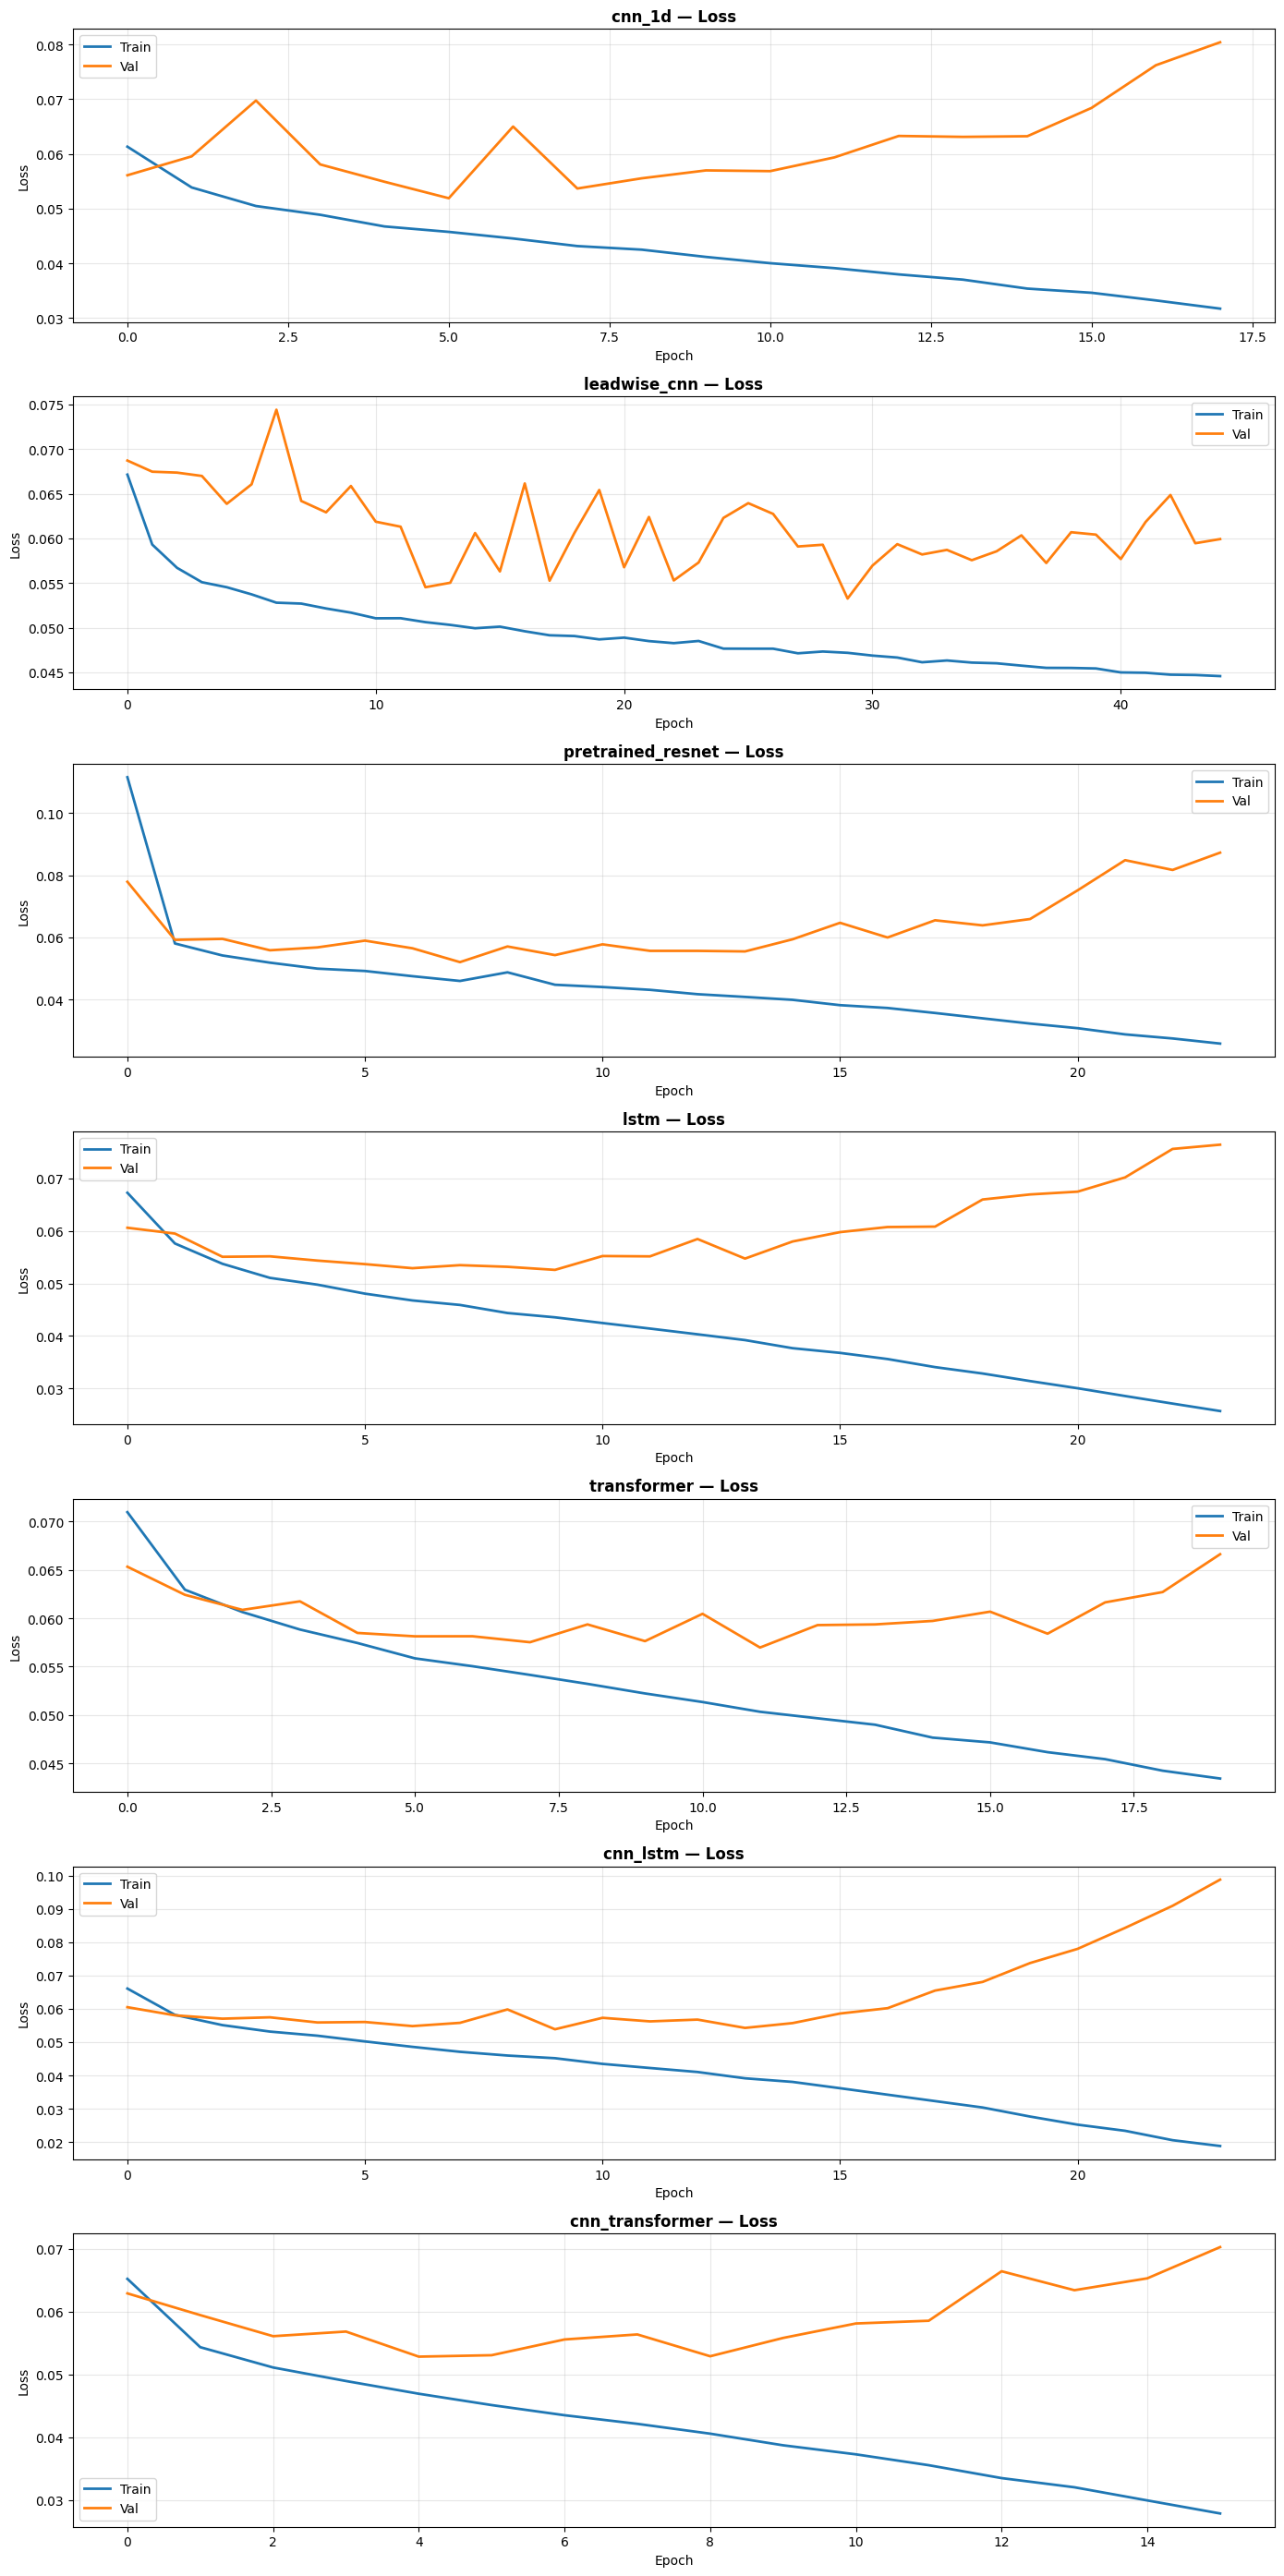

Saved to outputs/figures/all_training_histories.png


In [11]:
import matplotlib.pyplot as plt

run_ids = list(all_results.keys())
n_runs = len(run_ids)
fig, axes = plt.subplots(n_runs, 1, figsize=(14, 4 * n_runs))
if n_runs == 1: axes = [axes]

for ax, run_id in zip(axes, run_ids):
    h = all_results[run_id]['history']
    ax.plot(h['train_loss'], label='Train', linewidth=2)
    ax.plot(h['val_loss'], label='Val', linewidth=2)
    ax.set_title(f'{run_id} — Loss', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
fig_dir = Path("outputs/figures")
fig_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_dir / "all_training_histories.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {fig_dir / 'all_training_histories.png'}")

## 10. Download Outputs

In [12]:
# Save comparison summary
summary = {run_id: payload['metrics'] for run_id, payload in all_results.items()}
with open("outputs/model_comparison.json", 'w') as f:
    json.dump(summary, f, indent=2)

shutil.make_archive('outputs_archive', 'zip', '.', 'outputs')
print("📥 Download: outputs_archive.zip")
print("📂 Contains: models, results, figures for all trained runs")
print()
print("To use locally, extract into your project's outputs/ folder.")

📥 Download: outputs_archive.zip
📂 Contains: models, results, figures for all trained runs

To use locally, extract into your project's outputs/ folder.
